<a href="https://colab.research.google.com/github/OJB-Quantum/Spintronics-Generative-Layouts/blob/main/Nano_MTJ_Test_Array_No_Labels_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [3]:
# This code cell installs the required packages needed for the layout generation.

!python -m pip install -q uv
!uv pip install --system -q phidl gdstk ezdxf gdspy || python -m pip install -q phidl gdstk ezdxf gdspy

Generated layout: /content/Nano_MTJ_array_no_labels.gds
Spacing mode: electrode_edge_gap
Electrode bounding box: 360.000 µm wide × 110.000 µm tall
Actual electrode edge gaps: X = 40.000 µm, Y = 290.000 µm
Derived center-to-center pitch: X = 400.000 µm, Y = 400.000 µm
Layer map:
  FINS: GDS layer 4, datatype 0
  PADS: GDS layer 5, datatype 0
  PILLARS: GDS layer 30, datatype 0
  ELECTRODE: GDS layer 52, datatype 0


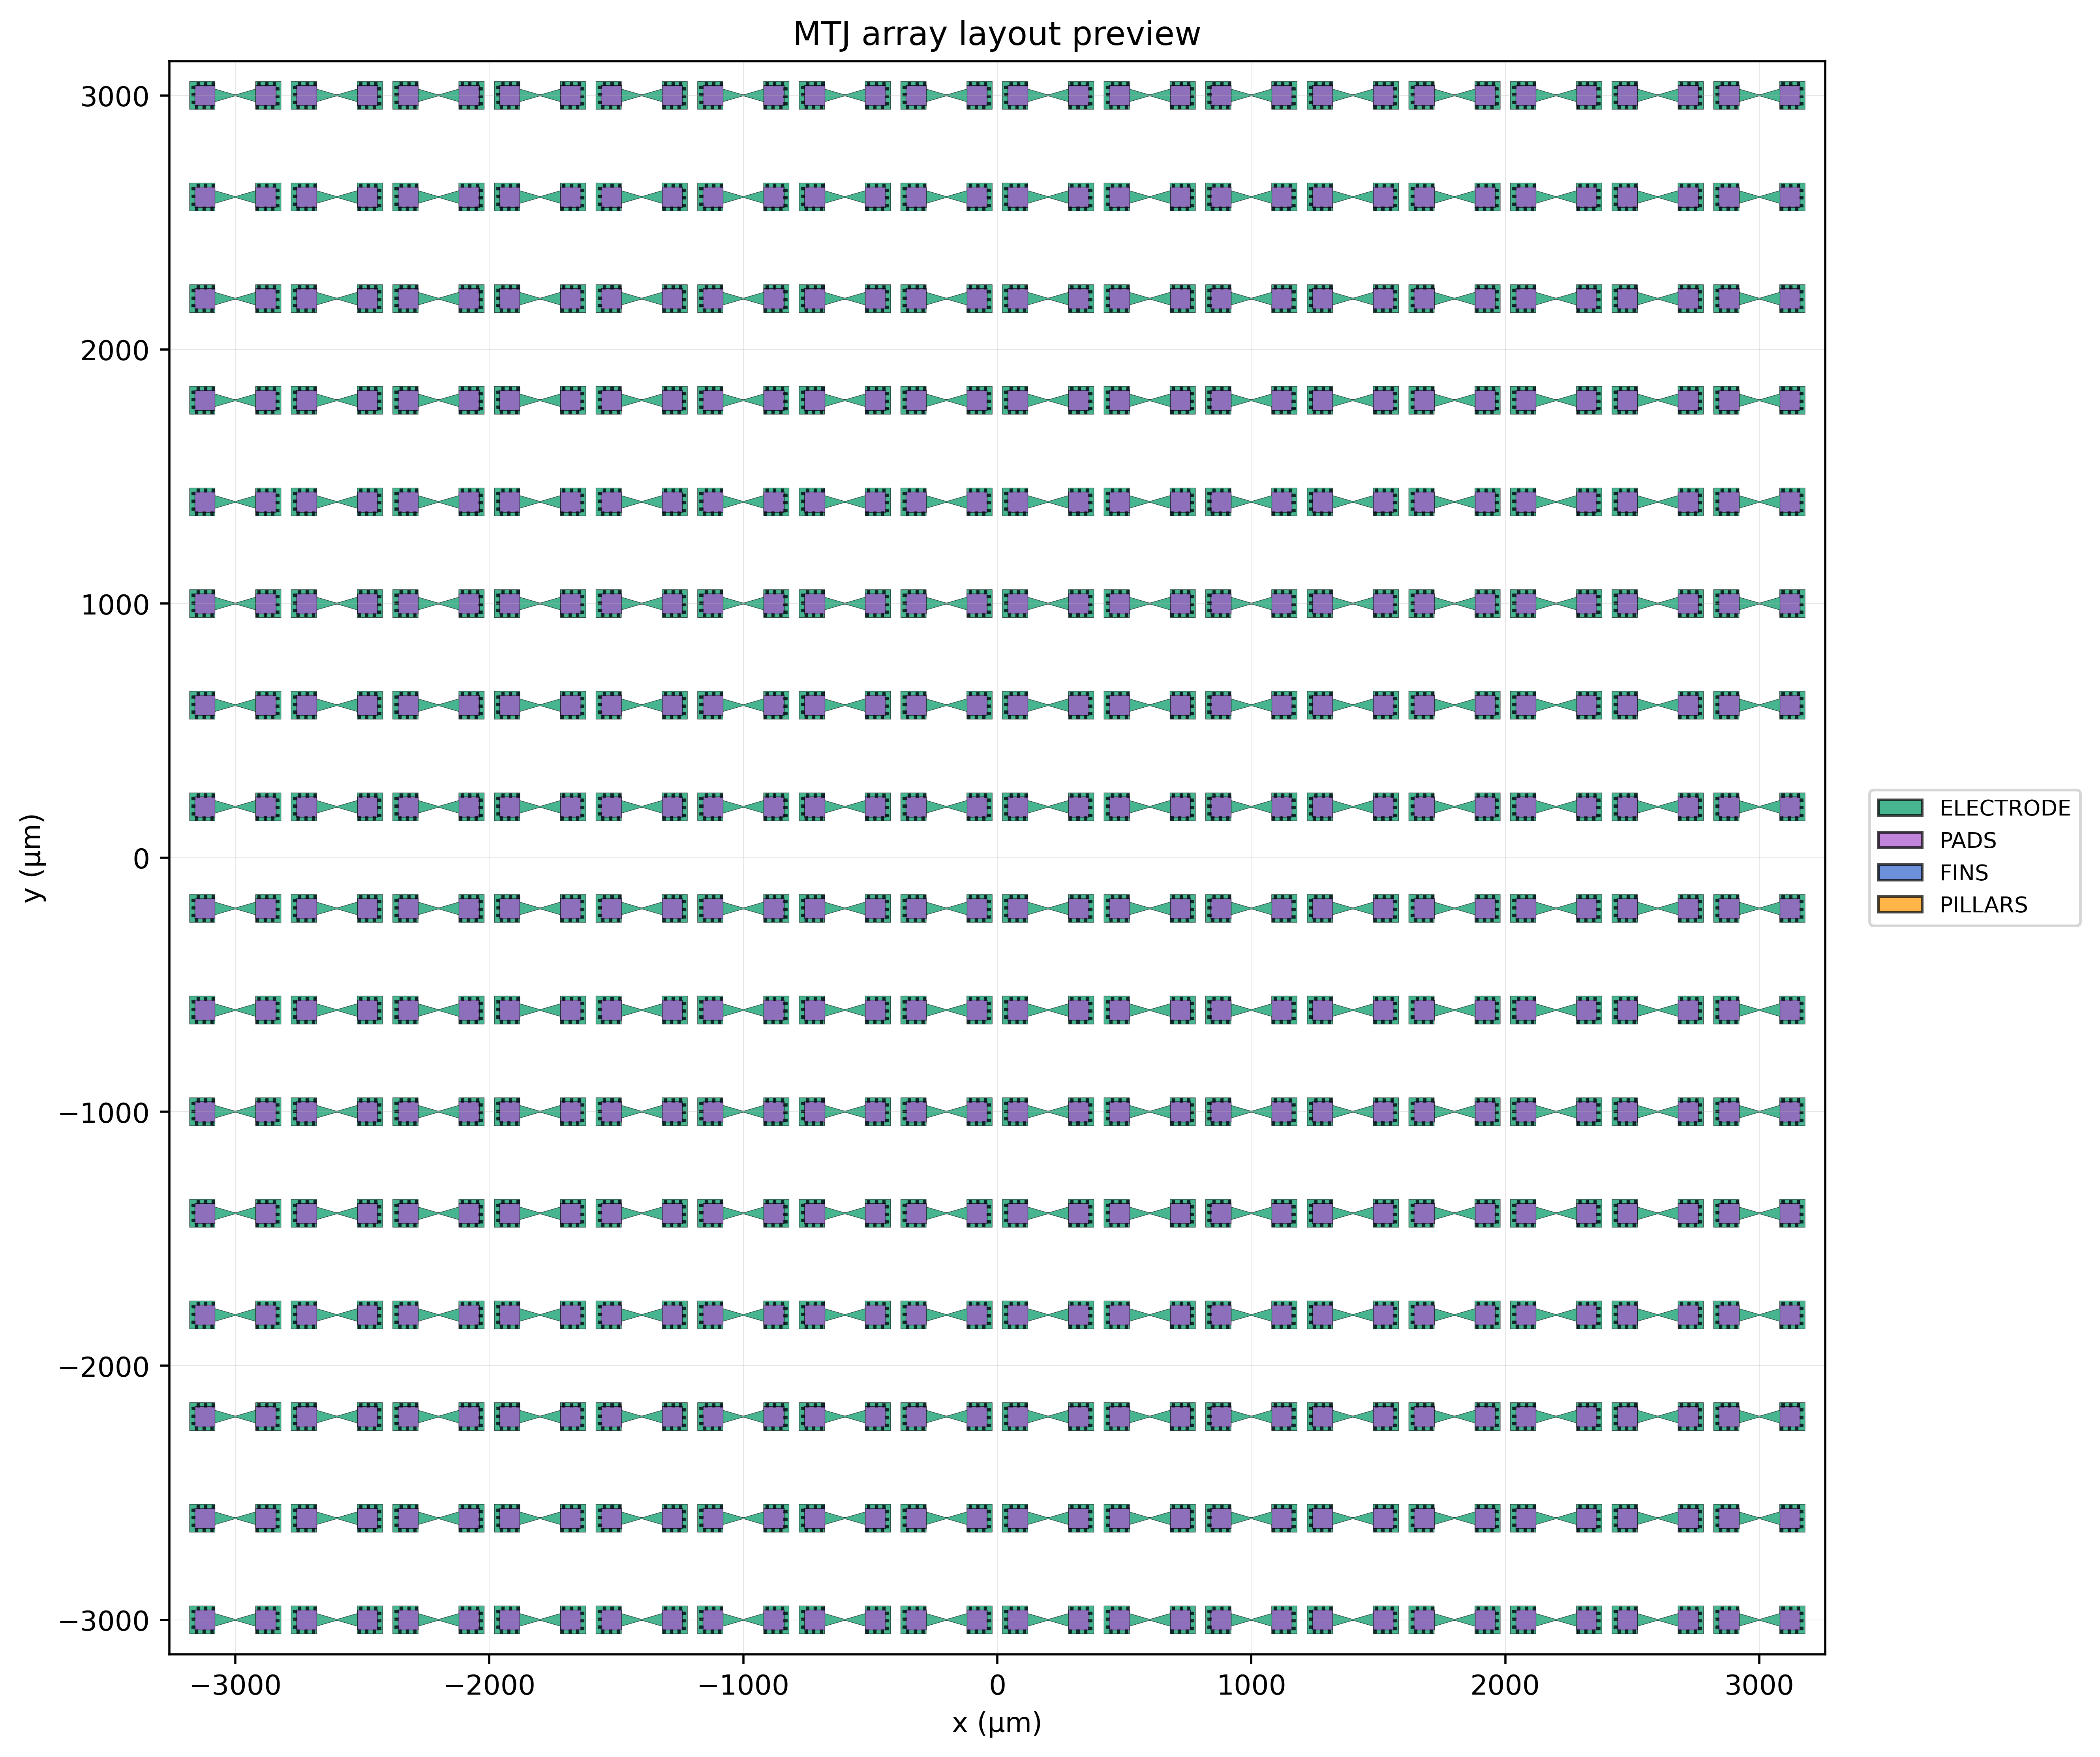

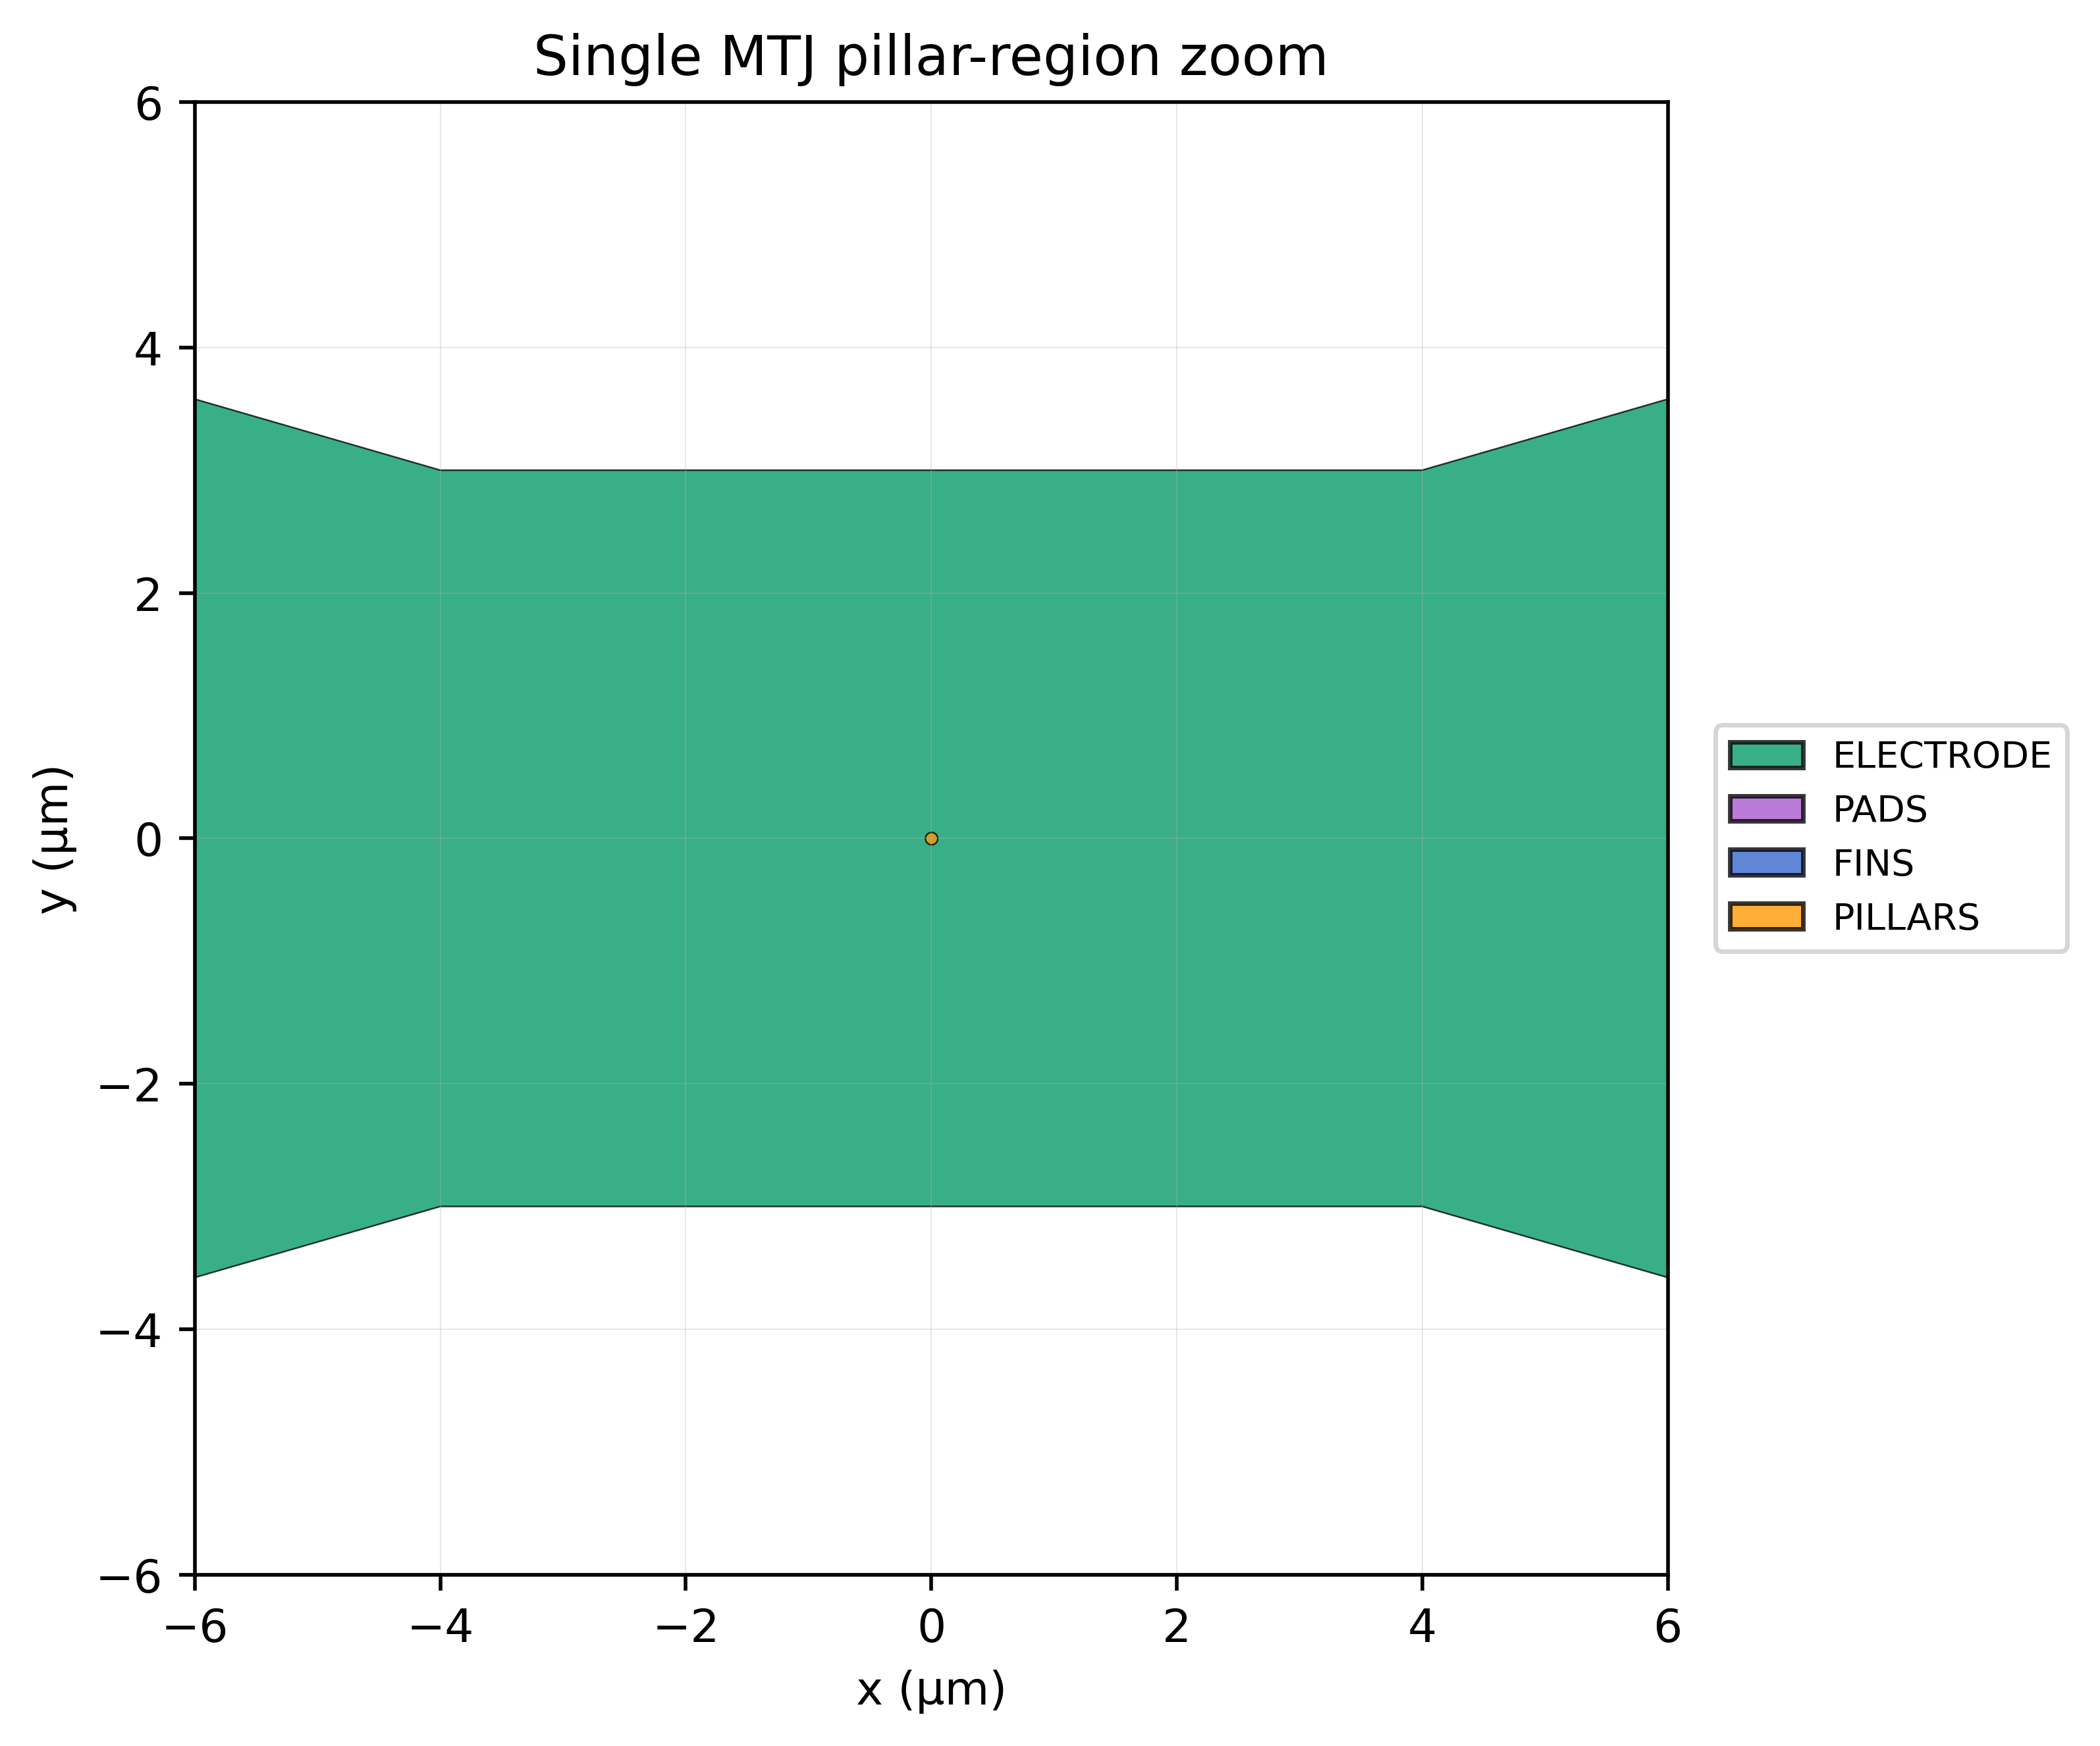

In [7]:
"""
Parameterized magnetic tunnel junction (MTJ) array.

The unit cell contains the electrode, pad, and fin geometries that are fixed. Meanwhile,
the pillar diameter, XY array dimensions, and electrode edge-to-edge spacing are adjustable.
Here, PHIDL is used for the layout geometry, and GDSTK is used for exporting the layout as a GDS
or OASIS file.
"""

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Final, Literal

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import gdstk
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from phidl import Device


# ---------------------------------------------------------------------------
# Control knobs.
# ---------------------------------------------------------------------------
OUTPUT_BASENAME: Final[str] = "Nano_MTJ_array_no_labels"
OUTPUT_FORMAT: Final[Literal["gds", "oas"]] = "gds"
OUTPUT_DIRECTORY: Final[Path] = Path.cwd()

# Set the desired MTJ pillar diameter and array size here.
PILLAR_DIAMETER_NM: Final[float] = 100.0
ARRAY_SIZE_X: Final[int] = 16
ARRAY_SIZE_Y: Final[int] = 16
CENTER_ARRAY_AT_ORIGIN: Final[bool] = True

ARRAY_SPACING_MODE: Final[Literal["electrode_edge_gap", "center_pitch"]] = (
    "electrode_edge_gap"
)

# Used when ARRAY_SPACING_MODE = "electrode_edge_gap".
ELECTRODE_EDGE_GAP_X_UM: Final[float] = 40.0
ELECTRODE_EDGE_GAP_Y_UM: Final[float] = 290.0

# Used when ARRAY_SPACING_MODE = "center_pitch".
ARRAY_CENTER_PITCH_X_UM: Final[float] = 430.0
ARRAY_CENTER_PITCH_Y_UM: Final[float] = 180.0

CIRCLE_POINTS: Final[int] = 900

GDS_UNIT_M: Final[float] = 1e-6
GDS_PRECISION_M: Final[float] = 1e-10

DISPLAY_AFTER_BUILD: Final[bool] = True
DISPLAY_SINGLE_UNIT_ZOOM: Final[bool] = True
WRITE_KLAYOUT_LAYER_PROPERTIES: Final[bool] = True
DOWNLOAD_AFTER_EXPORT_IN_COLAB: Final[bool] = False

# High-resolution preview controls.
PREVIEW_DPI: Final[int] = 500
PREVIEW_FIGSIZE_IN: Final[tuple[float, float]] = (12.0, 9.0)
PREVIEW_PADDING_UM: Final[float] = 80.0
PREVIEW_EDGE_LINEWIDTH: Final[float] = 0.18
PREVIEW_ALPHA: Final[float] = 0.72

UNIT_ZOOM_WINDOW_UM: Final[float] = 12.0
UNIT_ZOOM_FIGSIZE_IN: Final[tuple[float, float]] = (6.0, 6.0)
UNIT_ZOOM_DPI: Final[int] = 500

# Fixed DXF-derived geometry controls.
FIN_WIDTH_UM: Final[float] = 1.0
FIN_LENGTH_UM: Final[float] = 15.0
FIN_PITCH_UM: Final[float] = 2.5
FINS_PER_GROUP: Final[int] = 5

mpl.rcParams["figure.dpi"] = PREVIEW_DPI
mpl.rcParams["savefig.dpi"] = PREVIEW_DPI
mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"


@dataclass(frozen=True)
class LayerSpec:
    """Container for a named GDS layer/datatype pair."""

    name: str
    layer: int
    datatype: int
    color: str


@dataclass(frozen=True)
class BoundingBox:
    """Axis-aligned bounding box in micrometers."""

    xmin: float
    ymin: float
    xmax: float
    ymax: float

    @property
    def width(self) -> float:
        """Return bounding-box width."""
        return self.xmax - self.xmin

    @property
    def height(self) -> float:
        """Return bounding-box height."""
        return self.ymax - self.ymin


LAYERS: Final[dict[str, LayerSpec]] = {
    "FINS": LayerSpec("FINS", 4, 0, "#3366cc"),
    "PADS": LayerSpec("PADS", 5, 0, "#aa55cc"),
    "PILLARS": LayerSpec("PILLARS", 30, 0, "#ff9900"),
    "ELECTRODE": LayerSpec("ELECTRODE", 52, 0, "#009966"),
}

ELECTRODE_POLYGON_UM: Final[list[tuple[float, float]]] = [
    (-180.0, 55.0),
    (-180.0, -55.0),
    (-80.0, -55.0),
    (-80.0, -25.0),
    (-4.0, -3.0),
    (4.0, -3.0),
    (80.0, -25.0),
    (80.0, -55.0),
    (180.0, -55.0),
    (180.0, 55.0),
    (80.0, 55.0),
    (80.0, 25.0),
    (4.0, 3.0),
    (-4.0, 3.0),
    (-80.0, 25.0),
    (-80.0, 55.0),
]

PAD_POLYGONS_UM: Final[list[list[tuple[float, float]]]] = [
    [
        (-160.0, 40.0),
        (-80.0, 40.0),
        (-80.0, -40.0),
        (-160.0, -40.0),
    ],
    [
        (80.0, 40.0),
        (160.0, 40.0),
        (160.0, -40.0),
        (80.0, -40.0),
    ],
]


def polygon_bounding_box(
    points: list[tuple[float, float]],
) -> BoundingBox:
    """Return the axis-aligned bounding box of a polygon."""
    array = np.asarray(points, dtype=float)

    return BoundingBox(
        xmin=float(np.min(array[:, 0])),
        ymin=float(np.min(array[:, 1])),
        xmax=float(np.max(array[:, 0])),
        ymax=float(np.max(array[:, 1])),
    )


def rectangle_points(
    center: tuple[float, float],
    size: tuple[float, float],
) -> list[tuple[float, float]]:
    """Return rectangle vertices from a center point and size."""
    center_x, center_y = center
    size_x, size_y = size
    half_x = 0.5 * size_x
    half_y = 0.5 * size_y

    return [
        (center_x - half_x, center_y - half_y),
        (center_x + half_x, center_y - half_y),
        (center_x + half_x, center_y + half_y),
        (center_x - half_x, center_y + half_y),
    ]


def circle_points(
    radius_um: float,
    number_of_points: int,
) -> list[tuple[float, float]]:
    """Return polygon vertices approximating a circle at the origin."""
    angles = np.linspace(0.0, 2.0 * np.pi, number_of_points, endpoint=False)

    return [
        (radius_um * np.cos(angle), radius_um * np.sin(angle))
        for angle in angles
    ]


def stepped_values(
    start_um: float,
    count: int,
    pitch_um: float,
) -> list[float]:
    """Return evenly spaced coordinate values."""
    return [start_um + index * pitch_um for index in range(count)]


def add_centered_rectangle(
    device: Device,
    center: tuple[float, float],
    size: tuple[float, float],
    layer_name: str,
) -> None:
    """Add a centered rectangle polygon on the selected named layer."""
    layer = LAYERS[layer_name]
    device.add_polygon(
        rectangle_points(center=center, size=size),
        layer=layer.layer,
    )


def add_dxf_fin_pattern(device: Device) -> None:
    """Add the fixed fin pattern extracted from the DXF cell."""
    vertical_fin_groups = [
        (-45.5, [-158.0, -128.0, -98.0]),
        (45.5, [-152.0, -122.0, -92.0]),
        (-45.5, [82.0, 112.0, 142.0]),
        (45.5, [88.0, 118.0, 148.0]),
    ]

    for y_center, x_starts in vertical_fin_groups:
        for x_start in x_starts:
            for x_center in stepped_values(
                x_start,
                FINS_PER_GROUP,
                FIN_PITCH_UM,
            ):
                add_centered_rectangle(
                    device=device,
                    center=(x_center, y_center),
                    size=(FIN_WIDTH_UM, FIN_LENGTH_UM),
                    layer_name="FINS",
                )

    horizontal_fin_groups = [
        (-165.5, [-32.0, -2.0, 28.0]),
        (165.5, [-38.0, -8.0, 22.0]),
    ]

    for x_center, y_starts in horizontal_fin_groups:
        for y_start in y_starts:
            for y_center in stepped_values(
                y_start,
                FINS_PER_GROUP,
                FIN_PITCH_UM,
            ):
                add_centered_rectangle(
                    device=device,
                    center=(x_center, y_center),
                    size=(FIN_LENGTH_UM, FIN_WIDTH_UM),
                    layer_name="FINS",
                )


def derive_array_pitch_um() -> tuple[float, float]:
    """Return array pitch from either edge gaps or direct center pitch."""
    electrode_bbox = polygon_bounding_box(ELECTRODE_POLYGON_UM)

    if ARRAY_SPACING_MODE == "electrode_edge_gap":
        pitch_x_um = electrode_bbox.width + ELECTRODE_EDGE_GAP_X_UM
        pitch_y_um = electrode_bbox.height + ELECTRODE_EDGE_GAP_Y_UM
        return pitch_x_um, pitch_y_um

    if ARRAY_SPACING_MODE == "center_pitch":
        return ARRAY_CENTER_PITCH_X_UM, ARRAY_CENTER_PITCH_Y_UM

    raise ValueError(
        "ARRAY_SPACING_MODE must be 'electrode_edge_gap' or 'center_pitch'."
    )


def compute_actual_electrode_edge_gaps_um(
    pitch_x_um: float,
    pitch_y_um: float,
) -> tuple[float, float]:
    """Return actual electrode edge gaps implied by the array pitch."""
    electrode_bbox = polygon_bounding_box(ELECTRODE_POLYGON_UM)
    gap_x_um = pitch_x_um - electrode_bbox.width
    gap_y_um = pitch_y_um - electrode_bbox.height

    return gap_x_um, gap_y_um


def validate_settings() -> None:
    """Validate user-facing control knobs."""
    valid_formats = {"gds", "oas"}
    valid_spacing_modes = {"electrode_edge_gap", "center_pitch"}

    if OUTPUT_FORMAT not in valid_formats:
        raise ValueError("OUTPUT_FORMAT must be either 'gds' or 'oas'.")

    if ARRAY_SPACING_MODE not in valid_spacing_modes:
        raise ValueError(
            "ARRAY_SPACING_MODE must be 'electrode_edge_gap' or "
            "'center_pitch'."
        )

    if PILLAR_DIAMETER_NM <= 0.0:
        raise ValueError("PILLAR_DIAMETER_NM must be positive.")

    if ARRAY_SIZE_X < 1 or ARRAY_SIZE_Y < 1:
        raise ValueError("ARRAY_SIZE_X and ARRAY_SIZE_Y must be at least 1.")

    if ELECTRODE_EDGE_GAP_X_UM < 0.0 or ELECTRODE_EDGE_GAP_Y_UM < 0.0:
        raise ValueError(
            "ELECTRODE_EDGE_GAP_X_UM and ELECTRODE_EDGE_GAP_Y_UM "
            "must be nonnegative."
        )

    if ARRAY_CENTER_PITCH_X_UM <= 0.0 or ARRAY_CENTER_PITCH_Y_UM <= 0.0:
        raise ValueError(
            "ARRAY_CENTER_PITCH_X_UM and ARRAY_CENTER_PITCH_Y_UM "
            "must be positive."
        )

    if CIRCLE_POINTS < 32:
        raise ValueError("CIRCLE_POINTS should be at least 32.")

    pitch_x_um, pitch_y_um = derive_array_pitch_um()
    actual_gap_x_um, actual_gap_y_um = compute_actual_electrode_edge_gaps_um(
        pitch_x_um,
        pitch_y_um,
    )

    if actual_gap_x_um < 0.0 or actual_gap_y_um < 0.0:
        raise ValueError(
            "The selected pitch makes neighboring electrode bounding boxes "
            "overlap. Increase the pitch or use nonnegative edge gaps."
        )


def make_single_mtj_unit(pillar_diameter_nm: float) -> Device:
    """Create a single MTJ unit cell with fixed electrodes and pads."""
    unit = Device("MTJ_UNIT_FIXED_ELECTRODES")
    pillar_radius_um = 0.5 * pillar_diameter_nm * 1e-3

    unit.add_polygon(
        ELECTRODE_POLYGON_UM,
        layer=LAYERS["ELECTRODE"].layer,
    )

    for pad_polygon in PAD_POLYGONS_UM:
        unit.add_polygon(
            pad_polygon,
            layer=LAYERS["PADS"].layer,
        )

    add_dxf_fin_pattern(unit)

    unit.add_polygon(
        circle_points(
            radius_um=pillar_radius_um,
            number_of_points=CIRCLE_POINTS,
        ),
        layer=LAYERS["PILLARS"].layer,
    )

    return unit


def make_mtj_array(
    unit: Device,
    columns: int,
    rows: int,
    pitch_x_um: float,
    pitch_y_um: float,
    center_array: bool,
) -> Device:
    """Create a hierarchical XY array of the MTJ unit cell."""
    top = Device("MTJ_ARRAY")

    if center_array:
        origin_x = -0.5 * (columns - 1) * pitch_x_um
        origin_y = -0.5 * (rows - 1) * pitch_y_um
    else:
        origin_x = 0.0
        origin_y = 0.0

    for row_index in range(rows):
        for column_index in range(columns):
            x_um = origin_x + column_index * pitch_x_um
            y_um = origin_y + row_index * pitch_y_um
            reference = top.add_ref(unit)
            reference.move(destination=(x_um, y_um))

    return top


def write_klayout_layer_properties(
    layer_specs: dict[str, LayerSpec],
    output_file: Path,
) -> None:
    """Write a KLayout layer-property file carrying display names."""
    entries = []

    for spec in layer_specs.values():
        entries.append(
            f"""  <properties>
    <frame-color>{spec.color}</frame-color>
    <fill-color>{spec.color}</fill-color>
    <dither-pattern>I0</dither-pattern>
    <line-style/>
    <valid>true</valid>
    <visible>true</visible>
    <transparent>false</transparent>
    <width>1</width>
    <marked>false</marked>
    <xfill>false</xfill>
    <animation>0</animation>
    <name>{spec.name}</name>
    <source>{spec.layer}/{spec.datatype}@1</source>
  </properties>"""
        )

    xml_text = (
        '<?xml version="1.0" encoding="utf-8"?>\n'
        "<layer-properties>\n"
        + "\n".join(entries)
        + "\n</layer-properties>\n"
    )
    output_file.write_text(xml_text, encoding="utf-8")


def export_layout(
    device: Device,
    output_directory: Path,
    basename: str,
    output_format: str,
) -> Path:
    """Export a PHIDL device as GDSII or OASIS."""
    output_directory.mkdir(parents=True, exist_ok=True)
    output_path = output_directory / f"{basename}.{output_format}"

    if output_format == "gds":
        device.write_gds(
            str(output_path),
            unit=GDS_UNIT_M,
            precision=GDS_PRECISION_M,
            auto_rename=True,
        )
    elif output_format == "oas":
        temporary_gds = output_directory / f"{basename}_temporary_bridge.gds"
        device.write_gds(
            str(temporary_gds),
            unit=GDS_UNIT_M,
            precision=GDS_PRECISION_M,
            auto_rename=True,
        )
        library = gdstk.read_gds(str(temporary_gds))
        library.write_oas(str(output_path))
        temporary_gds.unlink(missing_ok=True)

    return output_path


def get_layer_color_map(
    layer_specs: dict[str, LayerSpec],
) -> dict[tuple[int, int], str]:
    """Return a color map indexed by GDS layer/datatype."""
    return {
        (spec.layer, spec.datatype): spec.color
        for spec in layer_specs.values()
    }


def get_layer_name_map(
    layer_specs: dict[str, LayerSpec],
) -> dict[tuple[int, int], str]:
    """Return a layer-name map indexed by GDS layer/datatype."""
    return {
        (spec.layer, spec.datatype): spec.name
        for spec in layer_specs.values()
    }


def normalize_layer_key(layer_key: object) -> tuple[int, int]:
    """Return a normalized layer/datatype tuple from a PHIDL polygon key."""
    if isinstance(layer_key, tuple):
        if len(layer_key) >= 2:
            return int(layer_key[0]), int(layer_key[1])
        return int(layer_key[0]), 0

    return int(layer_key), 0


def plot_device_high_resolution(
    device: Device,
    layer_specs: dict[str, LayerSpec],
    title: str,
    figure_size: tuple[float, float],
    dpi: int,
    padding_um: float,
    linewidth: float,
    alpha: float,
    x_limits: tuple[float, float] | None = None,
    y_limits: tuple[float, float] | None = None,
) -> None:
    """Render a sharp Matplotlib preview of a PHIDL device."""
    polygons_by_spec = device.get_polygons(by_spec=True)
    color_map = get_layer_color_map(layer_specs)
    name_map = get_layer_name_map(layer_specs)

    fig, ax = plt.subplots(figsize=figure_size, dpi=dpi)
    all_vertices = []
    legend_handles = []

    for layer_key, polygons in polygons_by_spec.items():
        normalized_key = normalize_layer_key(layer_key)
        color = color_map.get(normalized_key, "#808080")
        layer_name = name_map.get(normalized_key, str(normalized_key))

        polygon_arrays = [
            np.asarray(polygon, dtype=float)
            for polygon in polygons
            if len(polygon) >= 3
        ]

        if not polygon_arrays:
            continue

        collection = PolyCollection(
            polygon_arrays,
            facecolors=color,
            edgecolors="black",
            linewidths=linewidth,
            alpha=alpha,
        )
        ax.add_collection(collection)
        all_vertices.extend(polygon_arrays)
        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor="black",
                label=layer_name,
                alpha=alpha,
            )
        )

    if all_vertices:
        stacked_vertices = np.vstack(all_vertices)
        xmin = float(np.min(stacked_vertices[:, 0]))
        xmax = float(np.max(stacked_vertices[:, 0]))
        ymin = float(np.min(stacked_vertices[:, 1]))
        ymax = float(np.max(stacked_vertices[:, 1]))

        if x_limits is None:
            ax.set_xlim(xmin - padding_um, xmax + padding_um)
        else:
            ax.set_xlim(*x_limits)

        if y_limits is None:
            ax.set_ylim(ymin - padding_um, ymax + padding_um)
        else:
            ax.set_ylim(*y_limits)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(title)
    ax.grid(True, linewidth=0.25, alpha=0.35)

    if legend_handles:
        ax.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
            fontsize=8,
        )

    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()


def download_from_colab(paths: list[Path]) -> None:
    """Download generated files when running inside Google Colab."""
    try:
        from google.colab import files as colab_files

        for path in paths:
            colab_files.download(str(path))
    except ImportError:
        print("Colab download skipped outside Google Colab.")


validate_settings()

array_pitch_x_um, array_pitch_y_um = derive_array_pitch_um()
actual_edge_gap_x_um, actual_edge_gap_y_um = (
    compute_actual_electrode_edge_gaps_um(
        array_pitch_x_um,
        array_pitch_y_um,
    )
)

mtj_unit = make_single_mtj_unit(PILLAR_DIAMETER_NM)
top_device = make_mtj_array(
    unit=mtj_unit,
    columns=ARRAY_SIZE_X,
    rows=ARRAY_SIZE_Y,
    pitch_x_um=array_pitch_x_um,
    pitch_y_um=array_pitch_y_um,
    center_array=CENTER_ARRAY_AT_ORIGIN,
)

layout_path = export_layout(
    device=top_device,
    output_directory=OUTPUT_DIRECTORY,
    basename=OUTPUT_BASENAME,
    output_format=OUTPUT_FORMAT,
)

generated_paths = [layout_path]

if WRITE_KLAYOUT_LAYER_PROPERTIES:
    layer_property_path = OUTPUT_DIRECTORY / f"{OUTPUT_BASENAME}.lyp"
    write_klayout_layer_properties(LAYERS, layer_property_path)
    generated_paths.append(layer_property_path)

electrode_bbox = polygon_bounding_box(ELECTRODE_POLYGON_UM)

print(f"Generated layout: {layout_path}")
print(f"Spacing mode: {ARRAY_SPACING_MODE}")
print(
    "Electrode bounding box: "
    f"{electrode_bbox.width:.3f} µm wide × "
    f"{electrode_bbox.height:.3f} µm tall"
)
print(
    "Actual electrode edge gaps: "
    f"X = {actual_edge_gap_x_um:.3f} µm, "
    f"Y = {actual_edge_gap_y_um:.3f} µm"
)
print(
    "Derived center-to-center pitch: "
    f"X = {array_pitch_x_um:.3f} µm, "
    f"Y = {array_pitch_y_um:.3f} µm"
)
print("Layer map:")
for layer_name, layer_spec in LAYERS.items():
    print(
        f"  {layer_name}: "
        f"GDS layer {layer_spec.layer}, datatype {layer_spec.datatype}"
    )

if DISPLAY_AFTER_BUILD:
    plot_device_high_resolution(
        device=top_device,
        layer_specs=LAYERS,
        title="MTJ array layout preview",
        figure_size=PREVIEW_FIGSIZE_IN,
        dpi=PREVIEW_DPI,
        padding_um=PREVIEW_PADDING_UM,
        linewidth=PREVIEW_EDGE_LINEWIDTH,
        alpha=PREVIEW_ALPHA,
    )

if DISPLAY_SINGLE_UNIT_ZOOM:
    half_window_um = 0.5 * UNIT_ZOOM_WINDOW_UM
    plot_device_high_resolution(
        device=mtj_unit,
        layer_specs=LAYERS,
        title="Single MTJ pillar-region zoom",
        figure_size=UNIT_ZOOM_FIGSIZE_IN,
        dpi=UNIT_ZOOM_DPI,
        padding_um=0.0,
        linewidth=0.35,
        alpha=0.78,
        x_limits=(-half_window_um, half_window_um),
        y_limits=(-half_window_um, half_window_um),
    )

if DOWNLOAD_AFTER_EXPORT_IN_COLAB:
    download_from_colab(generated_paths)